<a href="https://colab.research.google.com/github/Dinithiii04/AgriLak/blob/yield-model-experiments/notebooks/DNN_NEW_WORKFLOW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Paddy Yield Forecasting - Data Pre-processing & Model Implementation




## Preprocessing Yield Dataset

In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [92]:
# Load the dataset
file_path = '/content/drive/MyDrive/NEW_yield_data.csv'

maha_yield = pd.read_csv(file_path)

In [93]:
# Display the first few rows to verify
display(maha_yield.head(10))


,District,Year,Yield,Cultivation_Season
0,PUTTALAM,1984,2158,1983-1984
1,MONARAGALA,1984,3074,1983-1984
2,JAFFNA,1984,1255,1983-1984
3,VAVUNIYA,1984,1992,1983-1984
4,MULLATIVU,1984,1153,1983-1984
5,MANNAR,1984,3644,1983-1984
6,ANURADHAPURA,1984,3144,1983-1984
7,POLONNARUWA,1984,3785,1983-1984
8,TRINCOMALEE,1984,2365,1983-1984
9,BATTICALOA,1984,2089,1983-1984


In [94]:
maha_yield.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 384 entries, 0 to 383
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   District            384 non-null    object
 1   Year                384 non-null    int64 
 2   Yield               384 non-null    int64 
 3   Cultivation_Season  384 non-null    object
dtypes: int64(2), object(2)
memory usage: 12.1+ KB


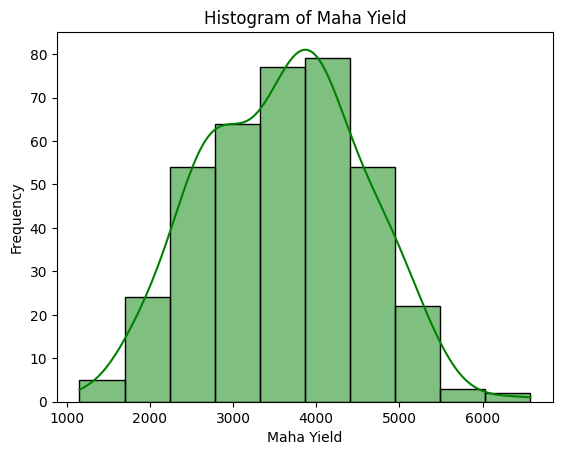

In [95]:
# Histogram of Maha yield
sns.histplot(maha_yield['Yield'], kde=True, bins=10, color='green')
plt.title('Histogram of Maha Yield')
plt.xlabel('Maha Yield')
plt.ylabel('Frequency')
plt.show()



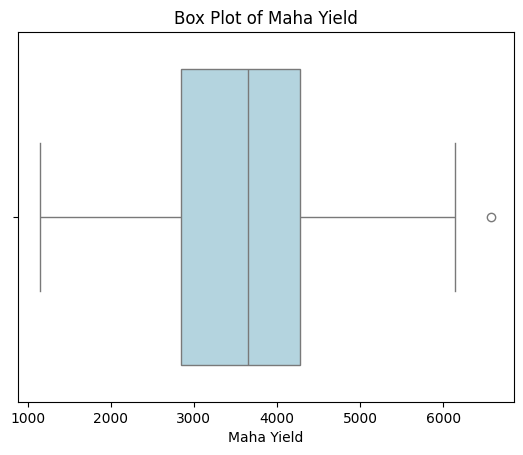

In [96]:
# Box Plot of Maha Yield
sns.boxplot(x=maha_yield['Yield'], color='lightblue')
plt.title('Box Plot of Maha Yield')
plt.xlabel('Maha Yield')
plt.show()

## Preprocessing Weather Dataset

In [97]:
file_path = '/content/drive/MyDrive/NEW_monthly_weather_data.csv'

# Load the dataset
weather_data = pd.read_csv(file_path)
weather_data.head()


,Year,Month,District,Tmax,Tmin,Wind,SRAD,RH,Rain,Soil
0,1984,1,BATTICALOA,27.56,24.17,3.65,12.71,85.08,331.78,0.92
1,1984,1,JAFFNA,27.17,23.67,5.03,13.10,84.14,192.61,0.97
2,1984,1,MANNAR,27.97,22.03,4.17,14.18,87.13,254.00,0.98
3,1984,1,MONARAGALA,27.58,18.59,1.68,13.96,92.02,279.90,0.89
4,1984,1,MULLATIVU,26.89,23.68,4.65,13.10,84.98,266.93,0.97


### Handling Missing Values

In [98]:
# Select only numeric columns
numeric_columns = weather_data.select_dtypes(include=['number'])

# Check for missing values in numeric columns
missing_values_numeric = numeric_columns.isnull().sum()
print("Missing Values:\n", missing_values_numeric, "\n")

# Check for negative values in numeric columns
negative_values_numeric = (numeric_columns < 0).sum()
print("Negative Values:\n", negative_values_numeric)


Missing Values:
 Year     0
Month    0
Tmax     0
Tmin     0
Wind     0
SRAD     0
RH       0
Rain     0
Soil     0
dtype: int64 

Negative Values:
 Year     0
Month    0
Tmax     0
Tmin     0
Wind     0
SRAD     0
RH       0
Rain     0
Soil     0
dtype: int64


### Determine Relevant Months for Maha Season

The Maha season in Sri Lanka spans from **September to March** in the following year, roughly covering **Standard Meteorological Weeks (SMWs) 36 to 13**, which crosses over two calendar years. This aligns with the North-East Monsoon and represents one of the two main paddy cultivation seasons in Sri Lanka, as defined by the *Department of Census and Statistics in Sri Lanka*.

### Filter Data for the Maha Season

In [99]:
# Define Maha season months
maha_months_full = [8, 9, 10, 11, 12, 1, 2]

maha_season_data = weather_data[
    (
        ((weather_data['Month'].isin([8, 9, 10, 11, 12])) & (weather_data['Year'] == 1984)) |
        ((weather_data['Month'].isin([1, 2])) & (weather_data['Year'] == 2015)) |
        ((weather_data['Month'].isin(maha_months_full)) & (weather_data['Year'] > 1984) & (weather_data['Year'] < 2015))
    )
]

# Display the filtered dataset
display(maha_season_data)


,Year,Month,District,Tmax,Tmin,Wind,SRAD,RH,Rain,Soil
84,1984,8,BATTICALOA,32.13,25.16,3.21,19.53,72.28,53.23,0.59
85,1984,8,JAFFNA,30.79,26.21,5.58,21.48,76.33,23.38,0.57
86,1984,8,MANNAR,31.07,25.38,5.20,21.30,78.19,14.91,0.57
87,1984,8,MONARAGALA,33.08,19.69,2.99,19.79,72.44,38.25,0.61
88,1984,8,MULLATIVU,31.27,25.69,5.43,21.48,77.58,30.63,0.60
...,...,...,...,...,...,...,...,...,...,...
4483,2015,2,TRINCOMALEE,28.96,23.48,4.05,18.29,79.58,163.27,0.81
4484,2015,2,VAVUNIYA,30.17,20.34,3.08,18.32,83.22,127.64,0.78
4485,2015,2,HAMBANTOTA,28.78,24.00,4.19,19.79,82.72,165.27,0.84
4486,2015,2,AMPARA,28.45,24.71,3.89,17.26,80.42,139.75,0.83


In [100]:
maha_season_data = maha_season_data.copy()

In [101]:
# Assign Cultivation Season based on months
maha_season_data['Cultivation_Season'] = np.where(
    maha_season_data['Month'] >= 8,
    maha_season_data['Year'].astype(str) + '-' + (maha_season_data['Year'] + 1).astype(str),
    (maha_season_data['Year'] - 1).astype(str) + '-' + maha_season_data['Year'].astype(str)
)

cols = list(maha_season_data.columns)
cols.insert(1, cols.pop(cols.index('Cultivation_Season')))

# Apply new column order
maha_season_data = maha_season_data[cols]

# Display modified dataframe
display(maha_season_data.head(20))


,Year,Cultivation_Season,Month,District,Tmax,Tmin,Wind,SRAD,RH,Rain,Soil
84,1984,1984-1985,8,BATTICALOA,32.13,25.16,3.21,19.53,72.28,53.23,0.59
85,1984,1984-1985,8,JAFFNA,30.79,26.21,5.58,21.48,76.33,23.38,0.57
86,1984,1984-1985,8,MANNAR,31.07,25.38,5.20,21.30,78.19,14.91,0.57
87,1984,1984-1985,8,MONARAGALA,33.08,19.69,2.99,19.79,72.44,38.25,0.61
88,1984,1984-1985,8,MULLATIVU,31.27,25.69,5.43,21.48,77.58,30.63,0.60
89,1984,1984-1985,8,POLONNARUWA,33.45,22.56,4.58,19.53,77.00,54.60,0.52
90,1984,1984-1985,8,PUTTALAM,30.67,23.83,5.09,21.30,83.33,15.56,0.61
91,1984,1984-1985,8,TRINCOMALEE,32.42,24.15,5.61,19.40,79.22,73.03,0.64
92,1984,1984-1985,8,VAVUNIYA,33.33,23.91,4.20,21.48,78.44,31.83,0.58
93,1984,1984-1985,8,HAMBANTOTA,29.04,24.43,6.09,19.79,84.41,45.28,0.67


## Merge Weather and Yield Data

In [102]:
maha_season_data = maha_season_data.drop(columns=['Year'])

# Merge the weather data with the yield data
merged_data = maha_season_data.merge(
    maha_yield,
    on=['District', 'Cultivation_Season'],
    how='inner'
)

display(merged_data.head(20))


,Cultivation_Season,Month,District,Tmax,Tmin,Wind,SRAD,RH,Rain,Soil,Year,Yield
0,1984-1985,8,BATTICALOA,32.13,25.16,3.21,19.53,72.28,53.23,0.59,1985,3163
1,1984-1985,8,JAFFNA,30.79,26.21,5.58,21.48,76.33,23.38,0.57,1985,1687
2,1984-1985,8,MANNAR,31.07,25.38,5.20,21.30,78.19,14.91,0.57,1985,3781
3,1984-1985,8,MONARAGALA,33.08,19.69,2.99,19.79,72.44,38.25,0.61,1985,2988
4,1984-1985,8,MULLATIVU,31.27,25.69,5.43,21.48,77.58,30.63,0.60,1985,2579
5,1984-1985,8,POLONNARUWA,33.45,22.56,4.58,19.53,77.00,54.60,0.52,1985,4874
6,1984-1985,8,PUTTALAM,30.67,23.83,5.09,21.30,83.33,15.56,0.61,1985,2643
7,1984-1985,8,TRINCOMALEE,32.42,24.15,5.61,19.40,79.22,73.03,0.64,1985,3379
8,1984-1985,8,VAVUNIYA,33.33,23.91,4.20,21.48,78.44,31.83,0.58,1985,2946
9,1984-1985,8,HAMBANTOTA,29.04,24.43,6.09,19.79,84.41,45.28,0.67,1985,4328


In [119]:
# Weather variables and month names in seasonal order
weather_variables = ['Tmax', 'Wind', 'SRAD', 'RH', 'Rain']
month_names = ['Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'Jan', 'Feb']
month_name_map = dict(zip([8, 9, 10, 11, 12, 1, 2], month_names))


In [120]:
# Create a copy of the data
pivot_data = merged_data.copy()

# Extract the yield year from the Cultivation_Season
pivot_data['Year'] = pivot_data['Cultivation_Season'].apply(lambda x: int(x.split('-')[1]))

# Pivot to wide format with month-specific columns
pivot_data = pivot_data.pivot_table(
    index=['Cultivation_Season', 'District', 'Year', 'Yield'],
    columns='Month',
    values=weather_variables,
    aggfunc='first'
)

# Flatten MultiIndex columns
pivot_data.columns = [f"{month_name_map[month]}_{var}" for var, month in pivot_data.columns]

# Reset index to keep 'Year' as a regular column
pivot_data = pivot_data.reset_index()

# Ensure the correct seasonal column order
ordered_columns = (
    ['Cultivation_Season', 'District', 'Year', 'Yield'] +
    [f"{month}_{var}" for month in month_names for var in weather_variables]
)

# Reorder the DataFrame columns
pivot_data = pivot_data[ordered_columns]

# Display the restructured DataFrame
display(pivot_data.head(20))


,Cultivation_Season,District,Year,Yield,Aug_Tmax,Aug_Wind,Aug_SRAD,Aug_RH,Aug_Rain,Sep_Tmax,Sep_Wind,Sep_SRAD,Sep_RH,Sep_Rain,Oct_Tmax,Oct_Wind,Oct_SRAD,Oct_RH,Oct_Rain,Nov_Tmax,Nov_Wind,Nov_SRAD,Nov_RH,Nov_Rain,Dec_Tmax,Dec_Wind,Dec_SRAD,Dec_RH,Dec_Rain,Jan_Tmax,Jan_Wind,Jan_SRAD,Jan_RH,Jan_Rain,Feb_Tmax,Feb_Wind,Feb_SRAD,Feb_RH,Feb_Rain
0,1984-1985,AMPARA,1985,3827,32.13,3.21,19.53,72.28,53.23,33.00,2.73,19.81,71.84,228.09,31.03,2.45,18.66,76.50,151.14,28.71,2.74,16.61,83.00,294.75,28.19,3.64,15.23,82.81,76.80,27.67,3.69,16.55,82.96,83.80,28.88,3.09,17.13,80.58,105.64
1,1984-1985,ANURADHAPURA,1985,3972,34.34,3.97,21.48,79.94,32.92,35.49,3.40,17.28,78.64,329.77,30.75,3.17,18.02,85.28,115.19,30.03,1.78,17.14,88.92,278.85,29.50,2.22,15.33,87.58,85.09,29.00,2.22,16.92,87.42,124.90,30.34,1.87,18.27,84.91,101.05
2,1984-1985,BATTICALOA,1985,3163,32.13,3.21,19.53,72.28,53.23,33.00,2.73,19.81,71.84,228.09,31.03,2.45,18.66,76.50,151.14,28.71,2.74,16.61,83.00,294.75,28.19,3.64,15.23,82.81,76.80,27.67,3.69,16.55,82.96,83.80,28.88,3.09,17.13,80.58,105.64
3,1984-1985,HAMBANTOTA,1985,4328,29.04,6.09,19.79,84.41,45.28,29.40,5.75,19.80,80.97,175.33,28.53,5.16,18.61,83.41,209.60,28.33,2.79,17.65,81.97,327.30,28.24,3.30,16.66,82.28,49.10,28.24,4.29,17.89,83.32,49.24,29.77,3.48,17.81,80.12,140.05
4,1984-1985,JAFFNA,1985,1687,30.79,5.58,21.48,76.33,23.38,30.54,4.98,19.14,77.73,233.21,29.12,5.29,17.76,79.45,101.59,28.77,4.34,15.47,81.68,226.04,27.82,4.76,13.99,79.70,94.21,28.00,4.53,15.37,80.37,93.75,29.31,3.69,18.94,76.36,69.66
5,1984-1985,MANNAR,1985,3781,31.07,5.20,21.30,78.19,14.91,31.28,4.72,20.31,79.26,250.99,29.41,4.65,18.62,81.69,91.90,29.19,3.41,16.57,84.00,256.05,28.43,3.85,15.75,82.49,87.11,28.28,3.79,16.17,82.88,96.02,30.46,3.09,18.96,79.24,104.83
6,1984-1985,MONARAGALA,1985,2988,33.08,2.99,19.79,72.44,38.25,34.37,2.40,19.80,72.62,170.26,32.09,2.02,18.61,80.14,199.65,28.56,1.33,17.65,88.76,237.55,29.15,1.68,16.66,88.40,52.62,27.75,1.91,17.89,88.97,48.98,30.99,1.58,17.81,83.43,96.24
7,1984-1985,MULLATIVU,1985,2579,31.27,5.43,21.48,77.58,30.63,31.51,4.69,19.14,77.84,294.18,29.60,5.11,17.76,80.73,103.23,28.90,3.97,15.47,82.82,262.20,27.69,4.71,13.99,80.46,104.56,27.65,4.29,15.37,80.89,97.90,28.94,3.52,18.94,78.01,63.14
8,1984-1985,POLONNARUWA,1985,4874,33.45,4.58,19.53,77.00,54.60,35.05,3.54,19.81,76.73,301.86,30.90,3.24,18.66,83.97,113.58,30.11,2.10,16.61,86.68,303.79,29.84,2.67,15.23,85.72,95.29,28.92,2.61,16.55,86.11,117.61,30.31,2.21,17.13,83.26,98.51
9,1984-1985,PUTTALAM,1985,2643,30.67,5.09,21.30,83.33,15.56,31.54,4.67,20.31,80.24,217.87,29.96,4.29,18.62,82.81,146.78,29.74,2.70,16.57,85.44,286.65,29.67,3.36,15.75,84.33,53.05,29.15,3.56,16.17,84.28,119.86,30.26,2.79,18.96,81.93,136.43


### Handling outliers

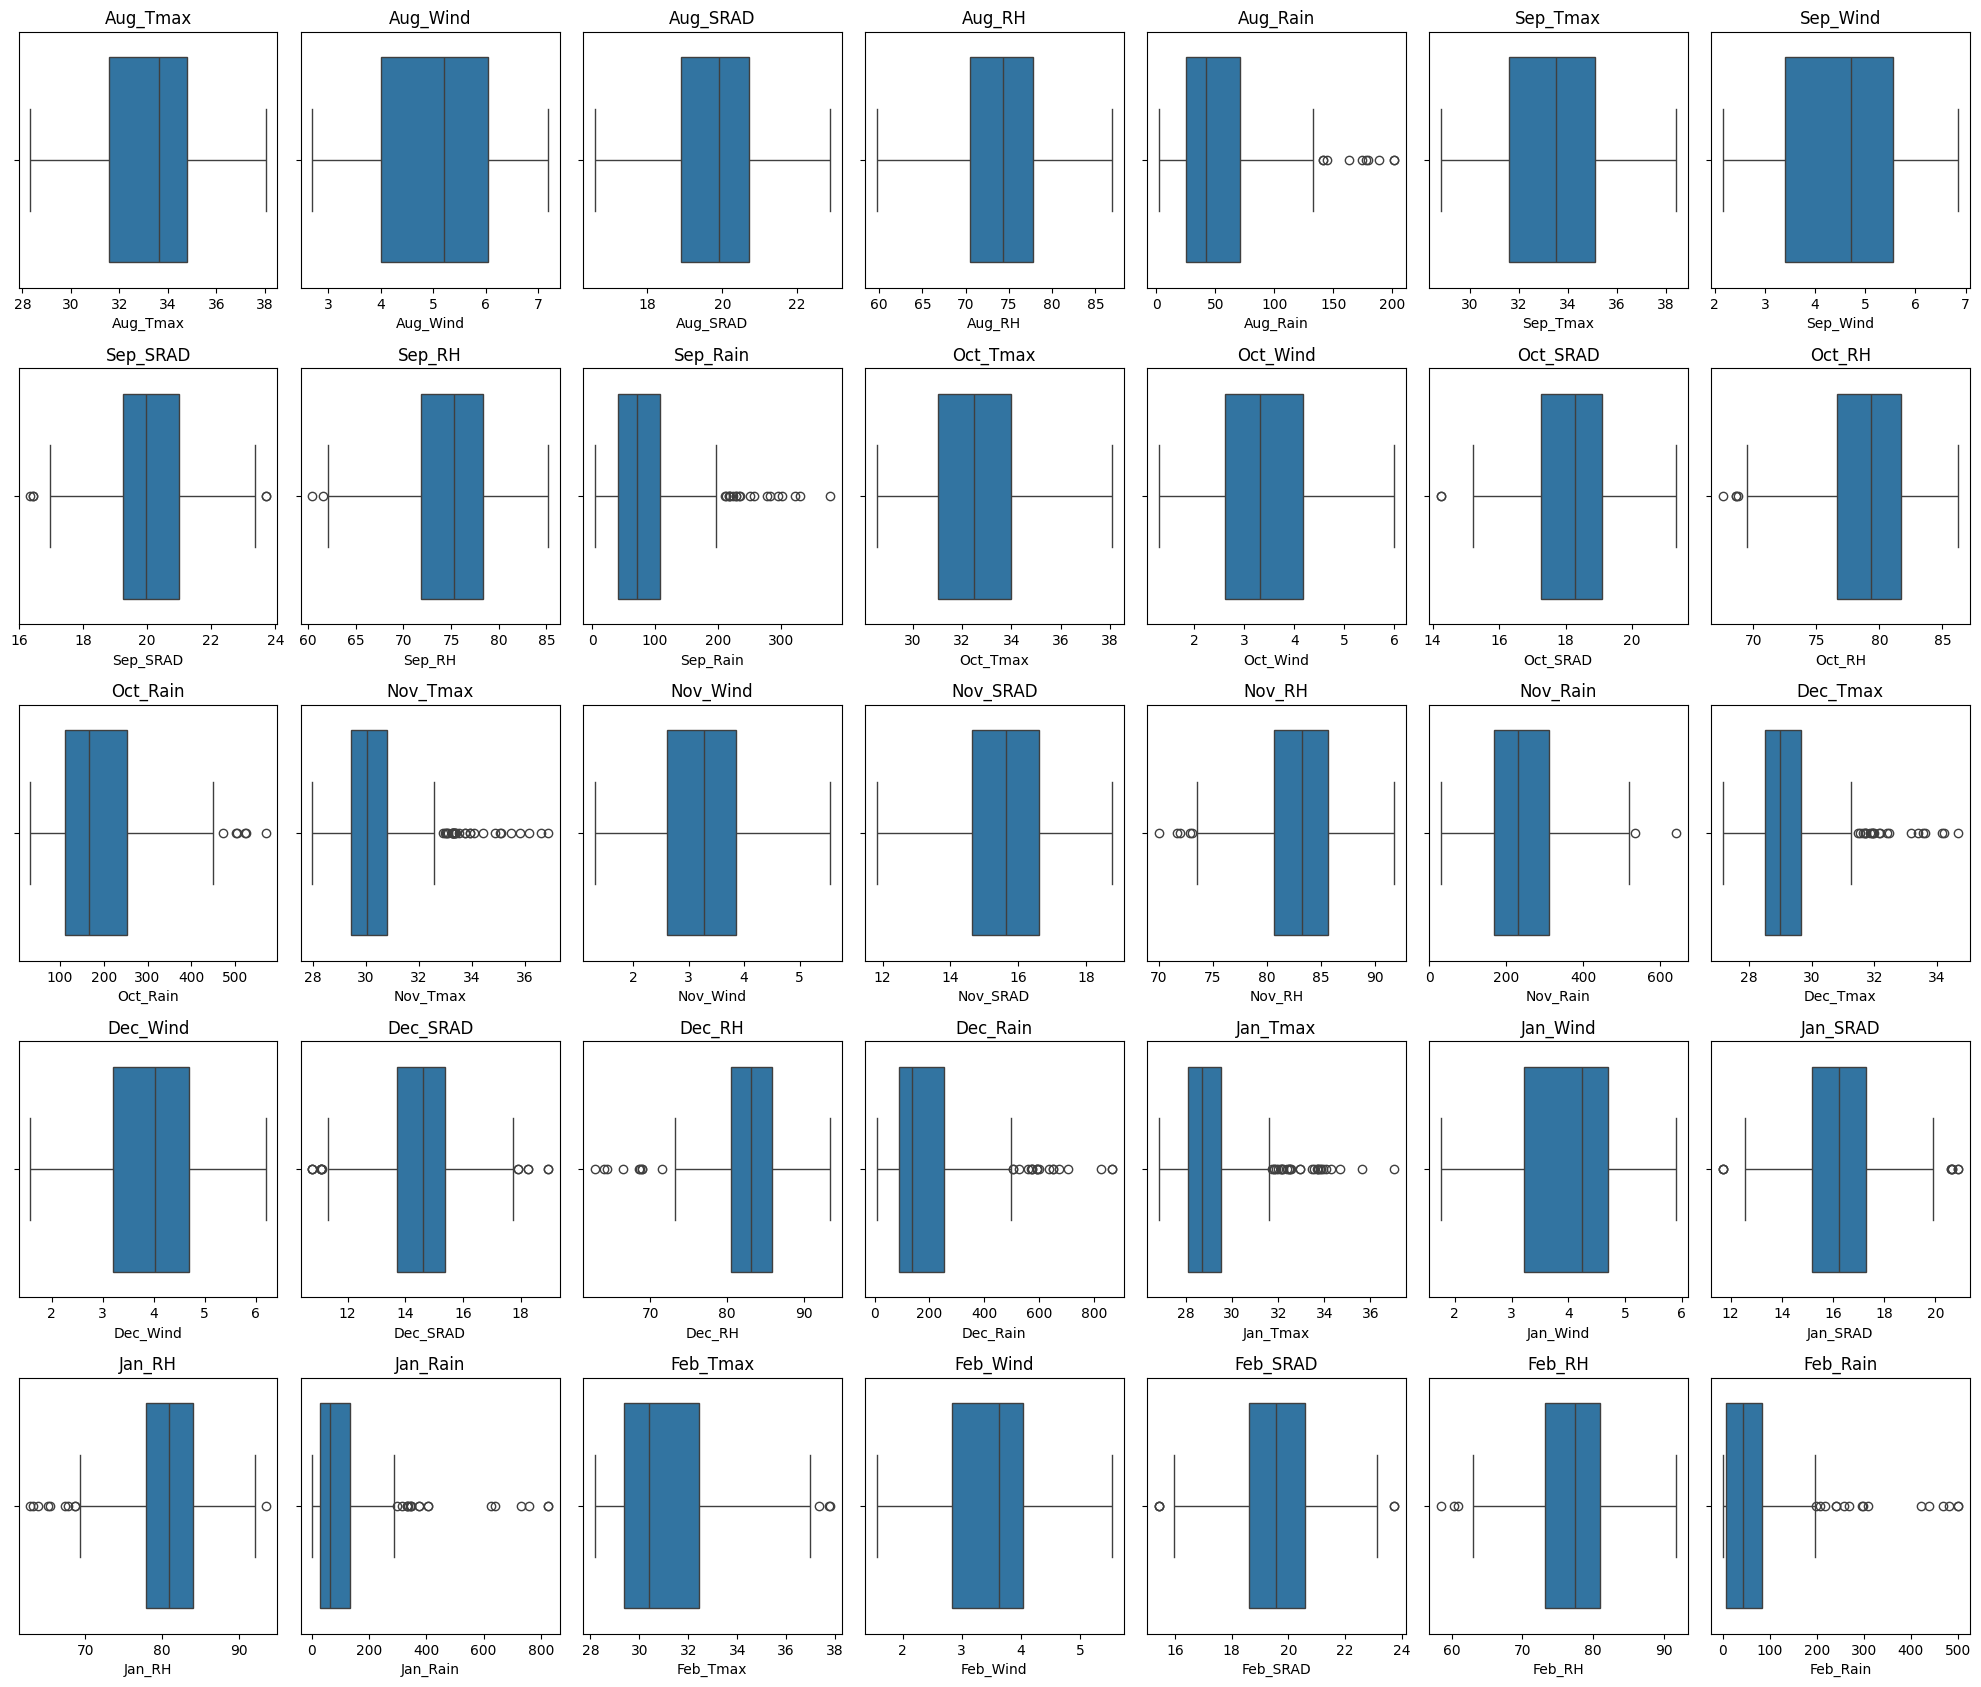

In [121]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select all weather variables excluding non-numeric columns
weather_columns = [col for col in pivot_data.columns if col not in ['Cultivation_Season', 'District', 'Year', 'Yield']]

# Generate horizontal box plots for each weather variable
plt.figure(figsize=(20, 30))

for i, variable in enumerate(weather_columns, start=1):
    plt.subplot(9, 7, i)
    sns.boxplot(x=pivot_data[variable])
    plt.title(f'{variable}')
    plt.xlabel(variable)

plt.tight_layout()
plt.show()


In [122]:
# Function to detect and print outliers based on IQR
def print_outlier_rows(df, columns):
    for variable in columns:
        Q1 = df[variable].quantile(0.25)  # First quartile
        Q3 = df[variable].quantile(0.75)  # Third quartile
        IQR = Q3 - Q1  # Interquartile range

        # Define outlier range
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Get rows containing outliers
        outlier_rows = df[(df[variable] < lower_bound) | (df[variable] > upper_bound)]

        # Print results
        if not outlier_rows.empty:
            print(f"\n=== Outliers for {variable} ===")
            display(outlier_rows)
        else:
            print(f"\nNo outliers detected for {variable}")

pd.set_option("display.max_columns", None)

# Call the function on your dataset
print_outlier_rows(pivot_data, weather_columns)



No outliers detected for Aug_Tmax

No outliers detected for Aug_Wind

No outliers detected for Aug_SRAD

No outliers detected for Aug_RH

=== Outliers for Aug_Rain ===


,Cultivation_Season,District,Year,Yield,Aug_Tmax,Aug_Wind,Aug_SRAD,Aug_RH,Aug_Rain,Sep_Tmax,Sep_Wind,Sep_SRAD,Sep_RH,Sep_Rain,Oct_Tmax,Oct_Wind,Oct_SRAD,Oct_RH,Oct_Rain,Nov_Tmax,Nov_Wind,Nov_SRAD,Nov_RH,Nov_Rain,Dec_Tmax,Dec_Wind,Dec_SRAD,Dec_RH,Dec_Rain,Jan_Tmax,Jan_Wind,Jan_SRAD,Jan_RH,Jan_Rain,Feb_Tmax,Feb_Wind,Feb_SRAD,Feb_RH,Feb_Rain
27,1986-1987,HAMBANTOTA,1987,4302,29.48,6.34,19.05,81.41,141.10,29.45,6.46,19.17,82.30,106.05,29.10,4.53,18.95,82.71,299.62,28.96,4.45,18.20,79.78,157.48,28.72,4.66,16.86,83.61,137.66,28.74,4.78,15.97,82.84,120.38,29.86,4.59,21.89,77.07,34.56
39,1987-1988,HAMBANTOTA,1988,4853,30.05,6.35,17.67,80.21,188.82,30.71,5.96,19.22,80.85,166.24,29.07,4.22,17.59,84.54,346.53,29.22,3.84,17.31,82.40,229.09,29.76,3.21,17.04,81.38,82.01,28.95,5.09,16.48,81.98,26.73,30.51,3.81,19.85,78.93,57.19
82,1990-1991,TRINCOMALEE,1991,3421,33.49,6.59,16.59,73.81,144.42,33.21,4.88,18.66,73.34,43.20,34.10,3.65,18.34,77.41,153.57,31.23,3.99,16.52,79.67,48.04,29.64,4.81,13.59,80.18,73.74,29.68,4.41,15.53,76.07,33.43,30.88,3.95,18.84,71.45,2.86
267,2006-2007,HAMBANTOTA,2007,5215,30.18,5.90,20.62,83.52,141.49,29.19,5.86,19.23,83.53,216.64,29.22,3.99,18.37,83.89,392.16,28.43,3.00,16.44,85.48,396.47,28.45,5.62,12.59,84.85,330.26,28.29,5.48,16.76,82.71,250.11,28.23,4.01,21.31,80.14,39.68
279,2007-2008,HAMBANTOTA,2008,4762,29.45,6.07,20.69,83.04,162.94,29.10,6.15,19.30,84.31,192.24,29.65,5.62,17.71,85.11,327.32,29.97,2.87,18.73,81.15,205.86,28.52,4.53,14.61,84.01,238.95,28.79,4.12,16.69,82.96,141.72,28.77,3.64,19.38,80.68,112.44
303,2009-2010,HAMBANTOTA,2010,5183,29.82,6.29,20.30,83.55,174.38,29.73,6.38,21.34,83.01,143.90,29.64,3.79,20.31,80.37,182.73,29.74,3.78,14.24,83.46,536.11,28.79,3.47,14.67,85.33,238.32,28.53,4.46,17.84,82.36,179.55,29.19,4.67,20.56,81.71,62.15
315,2010-2011,HAMBANTOTA,2011,5779,28.91,6.39,20.24,85.21,201.22,29.35,5.49,19.28,85.14,256.19,29.20,5.86,20.41,83.09,213.45,28.95,3.54,16.28,83.11,641.30,28.27,4.03,14.59,84.65,483.26,27.39,3.96,14.90,86.64,731.55,28.41,3.40,16.61,85.43,421.20
327,2011-2012,HAMBANTOTA,2012,5198,28.89,6.09,20.40,84.68,179.72,29.57,5.91,21.70,83.54,161.69,29.41,3.96,19.31,82.91,268.51,28.92,3.62,16.08,82.70,319.30,28.88,3.94,14.73,82.45,193.23,28.28,3.96,19.52,80.90,66.42,28.55,4.33,18.36,83.29,218.46
339,2012-2013,HAMBANTOTA,2013,6575,29.55,5.94,20.61,82.90,177.38,29.15,5.82,20.51,83.12,234.25,28.89,4.07,18.94,83.91,446.70,29.30,2.16,16.71,82.29,361.09,28.11,3.97,14.82,85.75,496.24,28.33,4.73,16.38,84.69,375.03,28.97,3.89,18.53,82.70,296.40
363,2014-2015,HAMBANTOTA,2015,6134,29.65,6.17,20.39,83.01,201.38,29.16,5.86,21.13,83.25,196.29,29.01,3.96,19.25,83.48,525.11,29.84,3.97,15.19,84.22,375.87,28.72,3.36,13.51,86.73,707.49,28.63,4.17,19.91,82.36,40.71,28.78,4.19,19.79,82.72,165.27



No outliers detected for Sep_Tmax

No outliers detected for Sep_Wind

=== Outliers for Sep_SRAD ===


,Cultivation_Season,District,Year,Yield,Aug_Tmax,Aug_Wind,Aug_SRAD,Aug_RH,Aug_Rain,Sep_Tmax,Sep_Wind,Sep_SRAD,Sep_RH,Sep_Rain,Oct_Tmax,Oct_Wind,Oct_SRAD,Oct_RH,Oct_Rain,Nov_Tmax,Nov_Wind,Nov_SRAD,Nov_RH,Nov_Rain,Dec_Tmax,Dec_Wind,Dec_SRAD,Dec_RH,Dec_Rain,Jan_Tmax,Jan_Wind,Jan_SRAD,Jan_RH,Jan_Rain,Feb_Tmax,Feb_Wind,Feb_SRAD,Feb_RH,Feb_Rain
147,1996-1997,HAMBANTOTA,1997,3995,30.59,6.85,17.46,79.23,40.53,30.28,6.85,16.45,82.35,48.04,31.29,5.67,16.98,80.02,50.84,30.74,4.17,16.65,76.57,84.64,30.40,4.09,16.39,76.34,26.25,30.36,5.20,19.76,72.03,2.66,30.62,4.45,20.06,70.46,21.27
150,1996-1997,MONARAGALA,1997,3292,35.51,3.78,17.46,62.72,24.40,35.40,3.56,16.45,65.36,24.35,36.15,2.40,16.98,68.66,42.87,36.62,1.81,16.65,69.96,93.37,34.16,1.96,16.39,75.60,22.45,35.63,2.56,19.76,69.37,3.21,35.07,2.31,20.06,64.56,11.97
154,1996-1997,TRINCOMALEE,1997,2269,33.79,5.92,17.58,72.18,26.56,33.60,6.02,16.36,74.77,30.77,33.63,4.23,17.04,74.51,66.73,33.25,3.78,14.51,75.33,66.35,31.72,3.98,14.80,75.79,27.41,30.65,4.36,17.47,71.06,5.60,30.58,3.98,18.75,69.26,1.39
221,2002-2003,MANNAR,2003,4271,32.23,5.90,21.69,76.81,9.99,32.60,5.88,23.70,72.00,7.85,31.95,3.51,18.83,81.32,293.82,29.40,3.08,16.10,85.13,120.19,29.01,4.75,14.63,84.17,128.50,29.07,4.77,17.90,80.61,73.06,31.58,3.98,21.53,77.95,46.81
225,2002-2003,PUTTALAM,2003,3108,32.12,5.45,21.69,79.87,39.92,33.64,5.46,23.70,71.73,18.07,32.90,3.28,18.83,83.77,325.80,29.93,2.65,16.10,86.10,170.66,30.06,4.23,14.63,86.58,166.77,29.72,4.36,17.90,83.94,72.50,32.42,3.66,21.53,80.39,43.65



=== Outliers for Sep_RH ===


...

,Cultivation_Season,District,Year,Yield,Aug_Tmax,Aug_Wind,Aug_SRAD,Aug_RH,Aug_Rain,Sep_Tmax,Sep_Wind,Sep_SRAD,Sep_RH,Sep_Rain,Oct_Tmax,Oct_Wind,Oct_SRAD,Oct_RH,Oct_Rain,Nov_Tmax,Nov_Wind,Nov_SRAD,Nov_RH,Nov_Rain,Dec_Tmax,Dec_Wind,Dec_SRAD,Dec_RH,Dec_Rain,Jan_Tmax,Jan_Wind,Jan_SRAD,Jan_RH,Jan_Rain,Feb_Tmax,Feb_Wind,Feb_SRAD,Feb_RH,Feb_Rain
293,2008-2009,MANNAR,2009,3670,31.39,5.38,20.61,77.63,35.32,32.57,5.71,23.36,74.33,5.59,33.50,3.75,19.10,76.18,145.32,31.51,4.08,15.76,78.48,211.48,29.19,4.39,16.57,81.70,145.04,29.65,4.36,18.80,76.64,22.72,33.86,3.56,23.73,68.67,0.08
297,2008-2009,PUTTALAM,2009,3976,31.08,5.03,20.61,80.17,48.78,32.54,4.87,23.36,77.21,32.23,33.00,3.19,19.10,78.96,250.07,31.29,3.31,15.76,81.53,186.92,30.17,3.99,16.57,83.82,106.47,31.45,4.22,18.80,77.96,35.24,35.84,3.36,23.73,66.48,0.05
312,2010-2011,AMPARA,2011,3333,34.01,3.14,19.99,72.28,110.11,33.70,2.29,19.76,74.98,144.85,32.17,2.74,20.04,77.57,158.83,30.33,2.92,15.51,82.93,519.15,28.86,3.67,12.05,84.64,574.49,27.17,5.01,11.69,86.80,823.98,28.42,3.58,15.42,82.22,500.14
314,2010-2011,BATTICALOA,2011,2399,34.01,3.14,19.99,72.28,110.11,33.70,2.29,19.76,74.98,144.85,32.17,2.74,20.04,77.57,158.83,30.33,2.92,15.51,82.93,519.15,28.86,3.67,12.05,84.64,574.49,27.17,5.01,11.69,86.80,823.98,28.42,3.58,15.42,82.22,500.14
320,2010-2011,POLONNARUWA,2011,3831,35.25,4.70,19.99,75.96,132.48,34.11,3.38,19.76,79.59,184.13,32.50,3.61,20.04,83.54,149.67,30.55,2.24,15.51,87.16,461.78,29.21,2.90,12.05,90.04,591.11,27.93,3.43,11.69,89.97,757.21,29.55,2.56,15.42,86.62,481.74



=== Outliers for Feb_RH ===


,Cultivation_Season,District,Year,Yield,Aug_Tmax,Aug_Wind,Aug_SRAD,Aug_RH,Aug_Rain,Sep_Tmax,Sep_Wind,Sep_SRAD,Sep_RH,Sep_Rain,Oct_Tmax,Oct_Wind,Oct_SRAD,Oct_RH,Oct_Rain,Nov_Tmax,Nov_Wind,Nov_SRAD,Nov_RH,Nov_Rain,Dec_Tmax,Dec_Wind,Dec_SRAD,Dec_RH,Dec_Rain,Jan_Tmax,Jan_Wind,Jan_SRAD,Jan_RH,Jan_Rain,Feb_Tmax,Feb_Wind,Feb_SRAD,Feb_RH,Feb_Rain
57,1988-1989,PUTTALAM,1989,2977,31.71,5.16,17.77,80.48,76.69,30.99,5.11,19.02,82.12,137.27,32.92,3.36,19.87,77.65,64.06,32.40,2.96,15.36,81.16,160.44,31.96,3.80,15.62,76.90,54.98,32.96,4.42,14.94,72.89,31.66,35.59,3.86,19.92,60.85,2.34
145,1996-1997,ANURADHAPURA,1997,3989,36.17,4.59,18.90,70.60,24.74,35.58,4.58,17.12,74.00,24.22,37.15,3.04,17.04,72.95,55.31,36.87,2.53,15.26,71.97,75.28,34.68,2.41,14.76,73.69,25.33,37.02,2.97,18.01,65.13,4.51,37.32,2.81,19.89,60.31,1.66
153,1996-1997,PUTTALAM,1997,3244,31.65,5.66,19.04,79.13,29.34,31.32,5.59,18.37,81.26,41.86,32.51,3.97,18.59,78.10,101.87,34.43,3.60,15.66,75.24,71.11,32.18,3.43,14.87,74.09,46.38,34.30,4.29,18.88,63.79,2.45,36.15,3.82,20.73,58.44,13.15



=== Outliers for Feb_Rain ===


,Cultivation_Season,District,Year,Yield,Aug_Tmax,Aug_Wind,Aug_SRAD,Aug_RH,Aug_Rain,Sep_Tmax,Sep_Wind,Sep_SRAD,Sep_RH,Sep_Rain,Oct_Tmax,Oct_Wind,Oct_SRAD,Oct_RH,Oct_Rain,Nov_Tmax,Nov_Wind,Nov_SRAD,Nov_RH,Nov_Rain,Dec_Tmax,Dec_Wind,Dec_SRAD,Dec_RH,Dec_Rain,Jan_Tmax,Jan_Wind,Jan_SRAD,Jan_RH,Jan_Rain,Feb_Tmax,Feb_Wind,Feb_SRAD,Feb_RH,Feb_Rain
312,2010-2011,AMPARA,2011,3333,34.01,3.14,19.99,72.28,110.11,33.70,2.29,19.76,74.98,144.85,32.17,2.74,20.04,77.57,158.83,30.33,2.92,15.51,82.93,519.15,28.86,3.67,12.05,84.64,574.49,27.17,5.01,11.69,86.80,823.98,28.42,3.58,15.42,82.22,500.14
313,2010-2011,ANURADHAPURA,2011,4463,35.62,4.29,18.02,75.57,102.56,35.03,3.24,18.50,78.75,212.75,31.58,3.29,18.33,85.79,122.66,30.57,1.81,14.42,88.81,373.30,29.26,2.58,11.08,91.71,429.14,28.32,2.84,12.85,90.85,374.59,30.46,2.23,16.46,88.49,308.19
314,2010-2011,BATTICALOA,2011,2399,34.01,3.14,19.99,72.28,110.11,33.70,2.29,19.76,74.98,144.85,32.17,2.74,20.04,77.57,158.83,30.33,2.92,15.51,82.93,519.15,28.86,3.67,12.05,84.64,574.49,27.17,5.01,11.69,86.80,823.98,28.42,3.58,15.42,82.22,500.14
315,2010-2011,HAMBANTOTA,2011,5779,28.91,6.39,20.24,85.21,201.22,29.35,5.49,19.28,85.14,256.19,29.20,5.86,20.41,83.09,213.45,28.95,3.54,16.28,83.11,641.30,28.27,4.03,14.59,84.65,483.26,27.39,3.96,14.90,86.64,731.55,28.41,3.40,16.61,85.43,421.20
318,2010-2011,MONARAGALA,2011,4077,32.54,3.05,20.24,76.54,90.68,33.30,2.18,19.28,77.80,135.95,32.93,2.25,20.41,81.61,154.32,29.80,1.40,16.28,88.31,511.10,28.53,1.94,14.59,91.66,505.81,26.82,2.42,14.90,93.45,639.91,28.17,1.84,16.61,91.75,439.17
320,2010-2011,POLONNARUWA,2011,3831,35.25,4.70,19.99,75.96,132.48,34.11,3.38,19.76,79.59,184.13,32.50,3.61,20.04,83.54,149.67,30.55,2.24,15.51,87.16,461.78,29.21,2.90,12.05,90.04,591.11,27.93,3.43,11.69,89.97,757.21,29.55,2.56,15.42,86.62,481.74
322,2010-2011,TRINCOMALEE,2011,2388,34.10,5.74,18.86,76.49,120.40,33.20,4.45,19.22,78.26,218.45,31.61,4.86,19.06,82.46,112.63,29.95,3.15,14.80,84.02,382.90,28.79,4.39,11.10,86.07,600.93,27.22,4.95,12.57,85.19,626.59,28.63,3.77,15.96,82.75,468.83
323,2010-2011,VAVUNIYA,2011,4139,34.99,4.44,18.02,74.75,96.93,33.69,3.48,18.50,78.06,197.12,31.93,3.65,18.33,84.79,121.47,30.66,2.24,14.42,86.42,412.31,29.29,3.26,11.08,89.59,450.15,27.82,3.65,12.85,88.06,314.74,29.97,2.93,16.46,85.93,258.07
327,2011-2012,HAMBANTOTA,2012,5198,28.89,6.09,20.40,84.68,179.72,29.57,5.91,21.70,83.54,161.69,29.41,3.96,19.31,82.91,268.51,28.92,3.62,16.08,82.70,319.30,28.88,3.94,14.73,82.45,193.23,28.28,3.96,19.52,80.90,66.42,28.55,4.33,18.36,83.29,218.46
336,2012-2013,AMPARA,2013,4084,34.53,3.42,20.94,69.18,33.06,34.15,3.06,20.78,72.27,83.24,32.69,3.20,18.23,80.24,347.28,29.76,2.75,16.27,81.71,288.97,28.31,3.95,13.31,83.94,593.23,27.83,4.40,14.52,81.40,405.59,29.10,3.59,17.60,81.03,239.79


### Correlation of Weather Variables with Final Yield

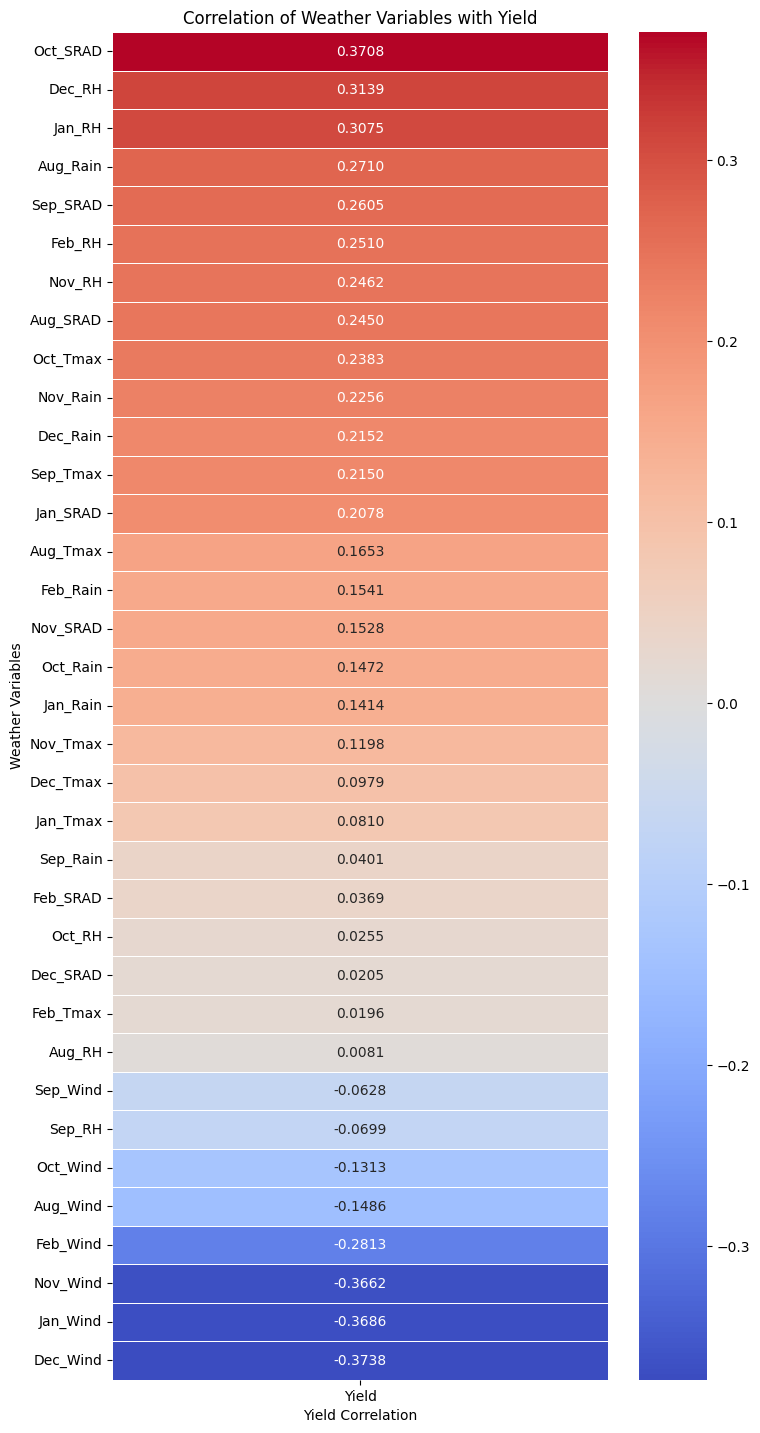

In [123]:
# Calculate the correlation of all weather variables with Yield
correlation_df = pivot_data[weather_columns + ['Yield']].corr()['Yield'].drop('Yield').sort_values(ascending=False)

# Convert to DataFrame for heatmap
correlation_matrix = correlation_df.to_frame()

# Plot the heatmap
plt.figure(figsize=(8, len(correlation_df) * 0.5))  # Adjust size based on number of variables
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".4f", linewidths=0.5, cbar=True)

# Titles and labels
plt.title("Correlation of Weather Variables with Yield")
plt.xlabel("Yield Correlation")
plt.ylabel("Weather Variables")

# Show the plot
plt.show()

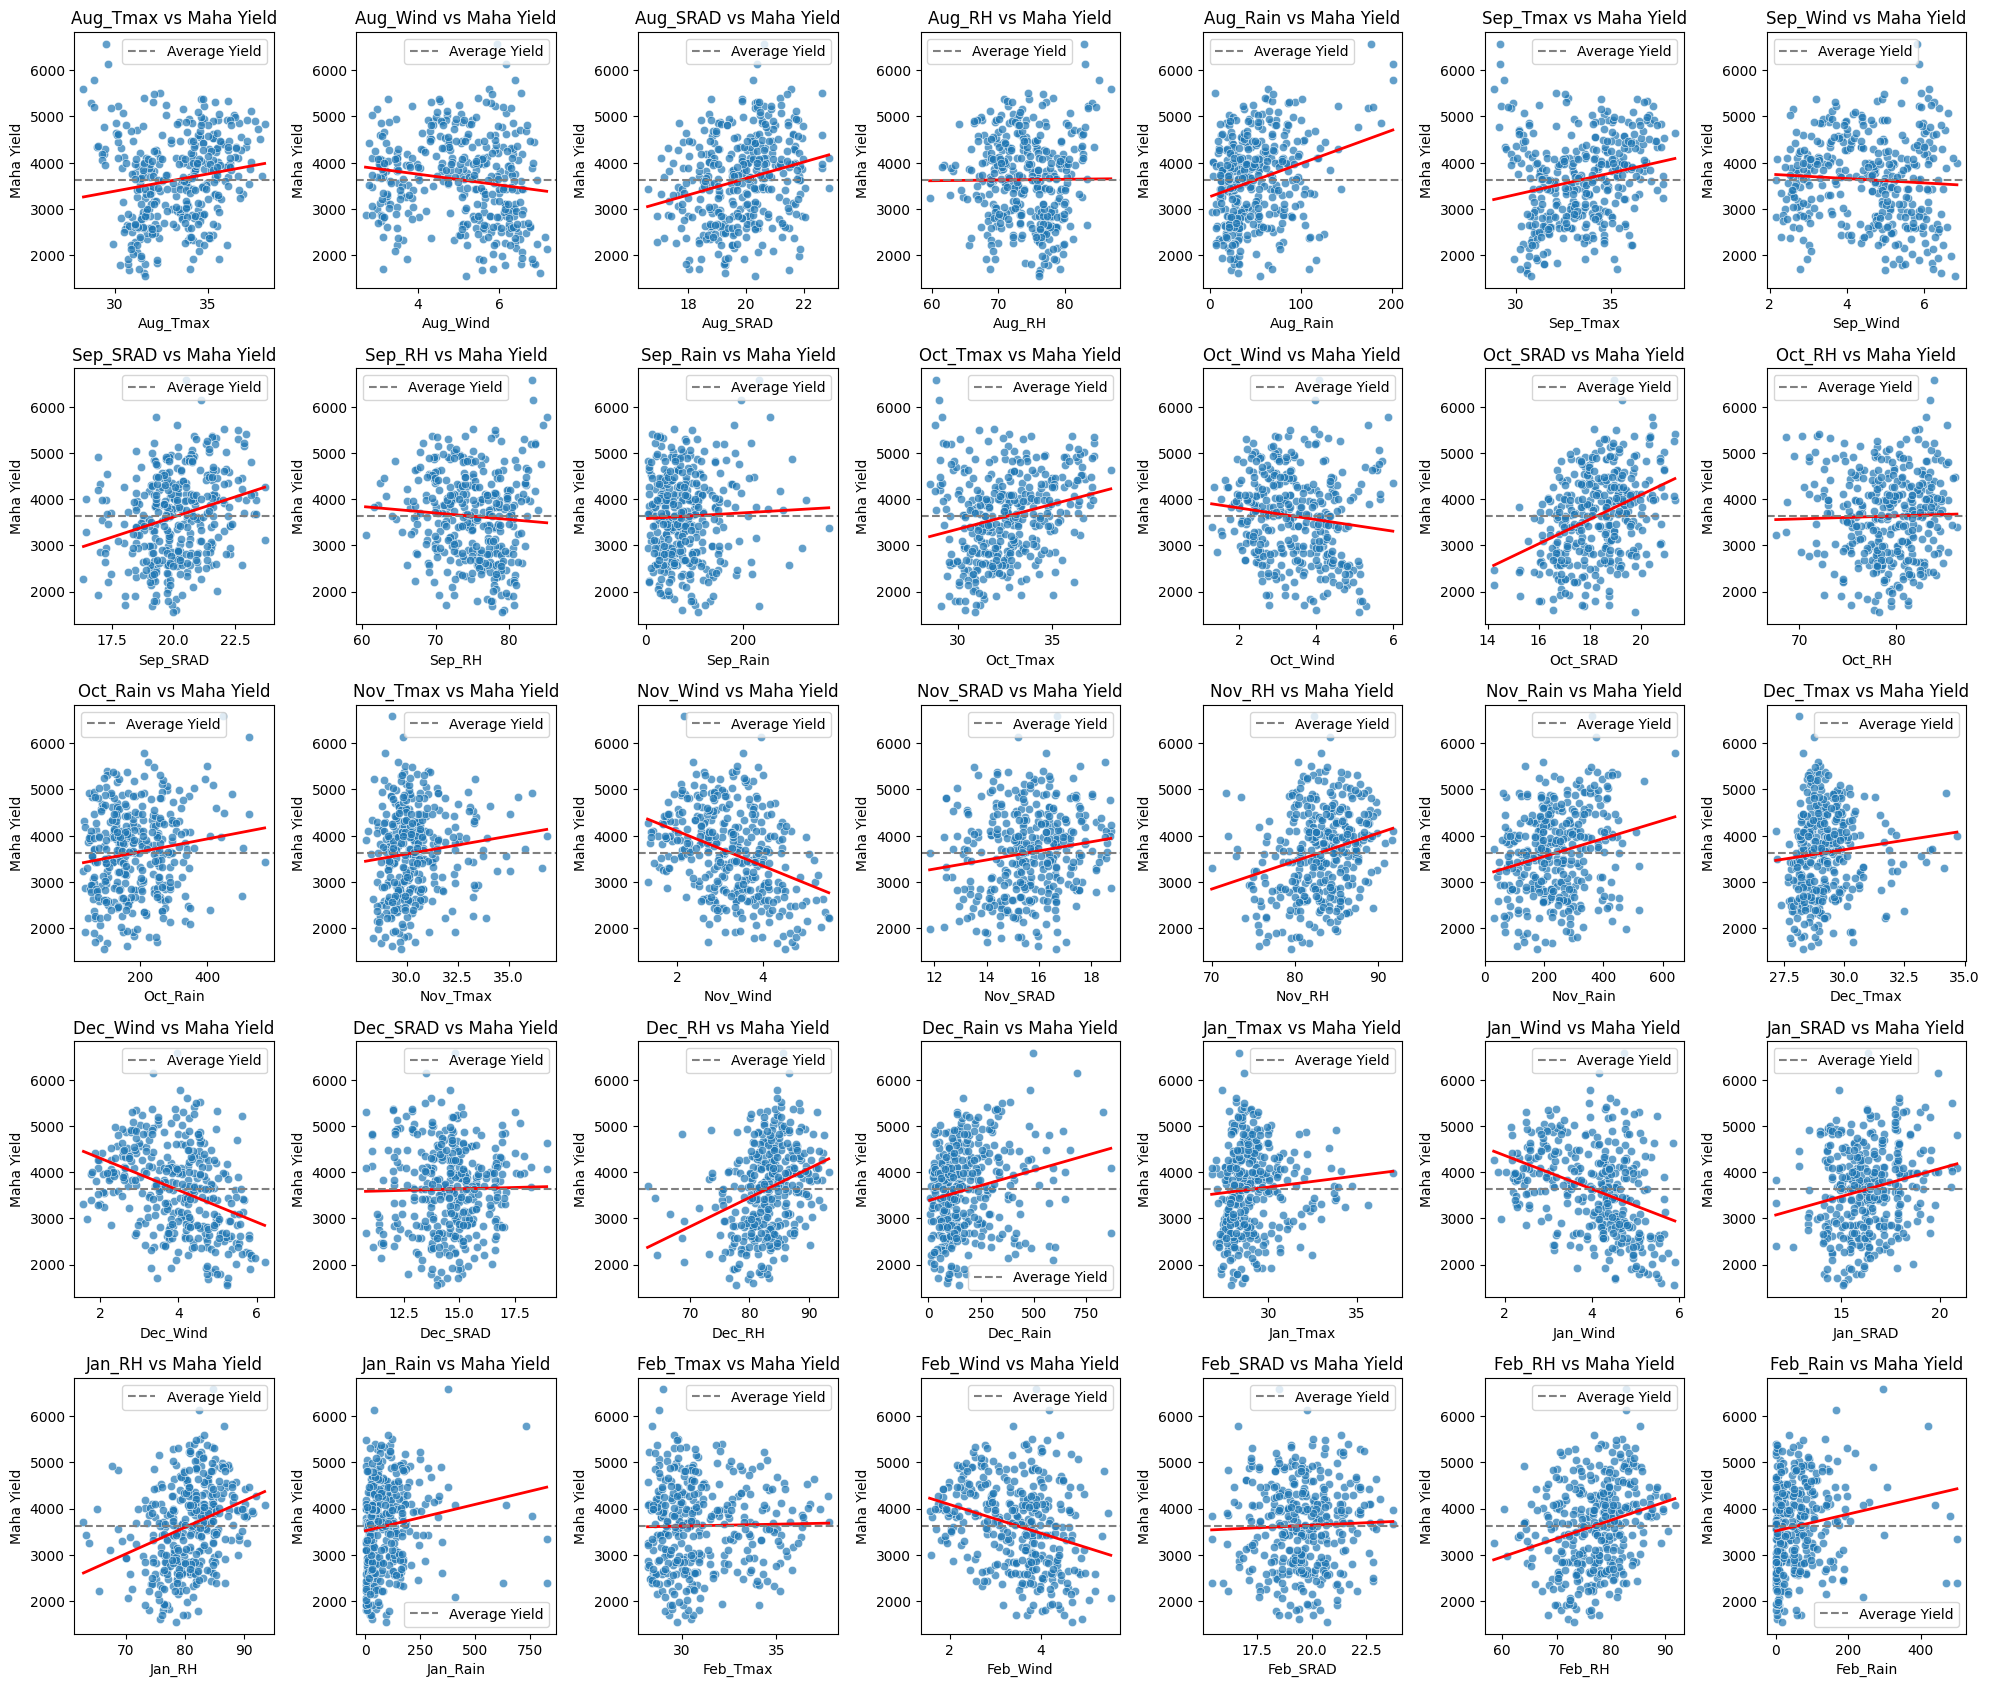

In [124]:
# Select all weather variables excluding non-numeric columns
weather_columns = [col for col in pivot_data.columns if col not in ['Cultivation_Season', 'District', 'Year', 'Yield']]

# Generate scatter plots with trend lines for each weather variable against Maha_Yield
plt.figure(figsize=(20, 30))

for i, variable in enumerate(weather_columns, start=1):
    plt.subplot(9, 7, i)
    sns.scatterplot(x=pivot_data[variable], y=pivot_data['Yield'], alpha=0.7)
    sns.regplot(x=pivot_data[variable], y=pivot_data['Yield'], scatter=False, ci=None, color='red', line_kws={"linewidth": 2})
    plt.title(f'{variable} vs Maha Yield')
    plt.xlabel(variable)
    plt.ylabel('Maha Yield')
    plt.axhline(y=pivot_data['Yield'].mean(), color='gray', linestyle='--', label='Average Yield')
    plt.legend()

plt.tight_layout()
plt.show()


In [125]:
# Drop the first three columns and create the final DataFrame
final_df = pivot_data.drop(columns=['Cultivation_Season', 'District', 'Year'])

# Display the first 20 rows of the final DataFrame
display(final_df.head())

,Yield,Aug_Tmax,Aug_Wind,Aug_SRAD,Aug_RH,Aug_Rain,Sep_Tmax,Sep_Wind,Sep_SRAD,Sep_RH,Sep_Rain,Oct_Tmax,Oct_Wind,Oct_SRAD,Oct_RH,Oct_Rain,Nov_Tmax,Nov_Wind,Nov_SRAD,Nov_RH,Nov_Rain,Dec_Tmax,Dec_Wind,Dec_SRAD,Dec_RH,Dec_Rain,Jan_Tmax,Jan_Wind,Jan_SRAD,Jan_RH,Jan_Rain,Feb_Tmax,Feb_Wind,Feb_SRAD,Feb_RH,Feb_Rain
0,3827,32.13,3.21,19.53,72.28,53.23,33.00,2.73,19.81,71.84,228.09,31.03,2.45,18.66,76.50,151.14,28.71,2.74,16.61,83.00,294.75,28.19,3.64,15.23,82.81,76.80,27.67,3.69,16.55,82.96,83.80,28.88,3.09,17.13,80.58,105.64
1,3972,34.34,3.97,21.48,79.94,32.92,35.49,3.40,17.28,78.64,329.77,30.75,3.17,18.02,85.28,115.19,30.03,1.78,17.14,88.92,278.85,29.50,2.22,15.33,87.58,85.09,29.00,2.22,16.92,87.42,124.90,30.34,1.87,18.27,84.91,101.05
2,3163,32.13,3.21,19.53,72.28,53.23,33.00,2.73,19.81,71.84,228.09,31.03,2.45,18.66,76.50,151.14,28.71,2.74,16.61,83.00,294.75,28.19,3.64,15.23,82.81,76.80,27.67,3.69,16.55,82.96,83.80,28.88,3.09,17.13,80.58,105.64
3,4328,29.04,6.09,19.79,84.41,45.28,29.40,5.75,19.80,80.97,175.33,28.53,5.16,18.61,83.41,209.60,28.33,2.79,17.65,81.97,327.30,28.24,3.30,16.66,82.28,49.10,28.24,4.29,17.89,83.32,49.24,29.77,3.48,17.81,80.12,140.05
4,1687,30.79,5.58,21.48,76.33,23.38,30.54,4.98,19.14,77.73,233.21,29.12,5.29,17.76,79.45,101.59,28.77,4.34,15.47,81.68,226.04,27.82,4.76,13.99,79.70,94.21,28.00,4.53,15.37,80.37,93.75,29.31,3.69,18.94,76.36,69.66


In [126]:
final_df.to_csv('/content/FINAL_yield_pred_data.csv', index=False)

## Split Data into Train-Test Sets

In [127]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

In [128]:
# Load dataset
df = pd.read_csv('/content/FINAL_yield_pred_data.csv')

# Perform 80-20 random train-test split
X = df.drop(columns=["Yield"])  # Features
y = df["Yield"]  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print dataset sizes
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Training samples: 297
Testing samples: 75


In [113]:
display(X_train.head())

,Aug_Tmax,Aug_Tmin,Aug_Wind,Aug_SRAD,Aug_RH,Aug_Rain,Aug_Soil,Sep_Tmax,Sep_Tmin,Sep_Wind,Sep_SRAD,Sep_RH,Sep_Rain,Sep_Soil,Oct_Tmax,Oct_Tmin,Oct_Wind,Oct_SRAD,Oct_RH,Oct_Rain,Oct_Soil,Nov_Tmax,Nov_Tmin,Nov_Wind,Nov_SRAD,Nov_RH,Nov_Rain,Nov_Soil,Dec_Tmax,Dec_Tmin,Dec_Wind,Dec_SRAD,Dec_RH,Dec_Rain,Dec_Soil,Jan_Tmax,Jan_Tmin,Jan_Wind,Jan_SRAD,Jan_RH,Jan_Rain,Jan_Soil,Feb_Tmax,Feb_Tmin,Feb_Wind,Feb_SRAD,Feb_RH,Feb_Rain,Feb_Soil
192,33.61,25.60,3.85,19.41,71.45,52.89,0.52,34.16,25.73,2.44,19.89,73.75,74.91,0.52,33.84,25.47,2.62,19.80,71.00,55.68,0.53,30.66,24.80,3.99,14.15,79.31,296.07,0.63,28.65,23.77,4.75,12.33,83.52,138.39,0.69,27.59,23.93,4.44,14.32,84.75,208.27,0.69,28.27,22.07,2.99,20.24,80.14,99.46,0.76
75,30.19,25.25,6.87,17.83,79.51,39.92,0.51,30.36,25.77,6.14,19.59,78.37,34.59,0.49,30.83,25.26,4.44,17.97,80.52,238.74,0.53,29.51,25.32,4.11,17.77,82.42,157.68,0.63,29.29,24.41,4.53,15.02,83.59,172.98,0.65,29.27,23.97,4.90,16.66,80.69,118.54,0.60,30.44,23.62,4.64,21.47,74.33,9.68,0.53
84,33.30,25.81,3.47,18.90,69.48,41.94,0.49,33.66,26.27,2.70,21.58,68.74,63.19,0.50,32.82,25.05,3.33,17.10,77.42,209.49,0.56,30.05,24.69,3.60,16.81,81.58,197.71,0.68,28.05,24.57,4.06,13.83,81.46,137.74,0.68,28.14,23.89,4.93,16.21,75.94,21.72,0.61,30.91,23.88,3.33,22.66,70.96,0.45,0.52
360,33.78,25.73,3.01,20.45,70.27,79.60,0.49,35.08,26.13,3.04,20.92,71.91,81.50,0.50,32.81,25.19,2.15,18.55,79.28,334.32,0.63,29.93,24.11,3.25,13.67,82.52,403.13,0.83,28.30,24.69,3.73,10.78,87.59,866.01,0.99,28.21,24.14,3.72,18.14,80.89,30.62,0.90,28.45,24.71,3.89,17.26,80.42,139.75,0.83
16,30.31,25.80,6.15,19.26,77.51,64.38,0.51,30.57,25.80,5.42,19.28,77.73,133.07,0.54,29.85,25.96,5.13,18.21,77.79,79.77,0.61,28.37,23.82,3.79,14.56,79.48,294.84,0.83,27.74,23.96,5.06,15.13,81.91,179.70,0.87,27.31,23.67,5.29,14.14,82.18,106.40,0.79,29.11,23.27,4.02,18.36,75.91,23.05,0.65


### Scale Data

In [114]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled data back to DataFrame (optional, for readability)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

# Print dataset sizes
print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Testing samples: {X_test_scaled.shape[0]}")

Training samples: 297
Testing samples: 75


In [115]:
display(X_train_scaled.head())

,Aug_Tmax,Aug_Tmin,Aug_Wind,Aug_SRAD,Aug_RH,Aug_Rain,Aug_Soil,Sep_Tmax,Sep_Tmin,Sep_Wind,Sep_SRAD,Sep_RH,Sep_Rain,Sep_Soil,Oct_Tmax,Oct_Tmin,Oct_Wind,Oct_SRAD,Oct_RH,Oct_Rain,Oct_Soil,Nov_Tmax,Nov_Tmin,Nov_Wind,Nov_SRAD,Nov_RH,Nov_Rain,Nov_Soil,Dec_Tmax,Dec_Tmin,Dec_Wind,Dec_SRAD,Dec_RH,Dec_Rain,Dec_Soil,Jan_Tmax,Jan_Tmin,Jan_Wind,Jan_SRAD,Jan_RH,Jan_Rain,Jan_Soil,Feb_Tmax,Feb_Tmin,Feb_Wind,Feb_SRAD,Feb_RH,Feb_Rain,Feb_Soil
0,0.107861,0.511821,-0.969308,-0.410252,-0.552300,0.084786,0.393545,0.311664,0.611332,-1.681160,-0.141404,-0.262207,-0.179935,0.161761,0.610963,0.737511,-0.792953,1.218708,-2.186964,-1.318960,-0.714176,0.251926,0.703820,0.790515,-0.955570,-1.005357,0.446469,-0.857971,-0.447252,0.638398,0.773927,-1.441746,0.113001,-0.372190,-0.640786,-0.981954,0.948138,0.444317,-1.214011,0.807969,0.936274,-0.277495,-1.229431,0.184076,-0.569115,0.451136,0.490887,0.454724,0.919788
1,-1.569406,0.277917,1.524486,-1.664503,1.145059,-0.289077,0.178687,-1.449344,0.636867,1.332685,-0.361016,0.740203,-0.845957,-0.431362,-0.865086,0.622873,1.066098,-0.194038,0.380661,0.534701,-0.714176,-0.590336,0.939469,0.917901,1.521217,-0.186585,-0.841130,-0.857971,0.172562,0.896704,0.558568,0.352811,0.127830,-0.149312,-0.934140,0.234844,0.963715,0.920229,0.249473,-0.029029,0.157813,-0.920812,-0.223712,0.772747,1.345582,1.249531,-0.557792,-0.683545,-0.812517
2,-0.044172,0.652163,-1.283097,-0.815105,-0.967163,-0.230850,-0.251030,0.079952,0.956053,-1.469377,1.095741,-1.349236,-0.373531,-0.233654,0.110773,0.508235,-0.067719,-0.865671,-0.455435,0.238517,-0.309643,-0.194839,0.653971,0.376511,0.864390,-0.407733,-0.468686,-0.425197,-1.028329,0.961280,0.098484,-0.441064,-0.323410,-0.376378,-0.714124,-0.583598,0.932561,0.951266,-0.031966,-1.008275,-0.682159,-0.849332,-0.005883,0.871492,-0.174571,2.021961,-1.166063,-0.800567,-0.887835
3,0.191234,0.598699,-1.662946,0.415331,-0.800797,0.854706,-0.251030,0.738013,0.866681,-1.192429,0.612596,-0.661435,-0.071079,-0.233654,0.105870,0.584660,-1.273038,0.253718,0.046223,1.502542,0.634268,-0.282727,0.391132,0.004968,-1.283984,-0.160258,1.442570,0.873125,-0.786214,1.009713,-0.224554,-2.475784,0.975230,4.316179,1.559369,-0.532898,1.029916,-0.300589,1.175096,0.012203,-0.604946,1.223577,-1.146008,1.186716,0.475265,-1.483185,0.541426,0.965538,1.447011
4,-1.510555,0.645480,0.929939,-0.529327,0.723878,0.415987,0.178687,-1.352025,0.656018,0.746207,-0.587948,0.601341,0.780776,0.557176,-1.345660,1.005001,1.770903,-0.008760,-0.355643,-1.075025,0.364579,-1.425274,0.259712,0.578205,-0.675050,-0.960601,0.435025,0.873125,-1.328551,0.715083,1.077386,0.426194,-0.228077,-0.106012,0.679307,-1.184754,0.846889,1.323719,-1.326586,0.278146,0.052491,0.437301,-0.840121,0.639822,0.626120,-0.769174,-0.272609,-0.514034,0.091294


In [130]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the model
model = keras.Sequential([
    layers.Dense(80, activation='relu', input_shape=(X_train_scaled.shape[1],)),  # Hidden layer with 80 neurons
    layers.Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Display the model architecture
model.summary()


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                     │ (None, 80)                  │           4,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 1)                   │              81 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,081 (15.94 KB)

 Trainable params: 4,081 (15.94 KB)

 Non-trainable params: 0 (0.00 B)

In [131]:
history = model.fit(
    X_train_scaled, y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    verbose=1
)


Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - loss: 14047118.0000 - mae: 3624.3999 - val_loss: 14864777.0000 - val_mae: 3763.0347
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - loss: 13676806.0000 - mae: 3574.9138 - val_loss: 14858199.0000 - val_mae: 3762.1711
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 13985809.0000 - mae: 3606.1016 - val_loss: 14850934.0000 - val_mae: 3761.2217
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 14606537.0000 - mae: 3703.2407 - val_loss: 14842911.0000 - val_mae: 3760.1721
Epoch 5/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 14092221.0000 - mae: 3632.3931 - val_loss: 14834328.0000 - val_mae: 3759.0518
Epoch 6/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 13632935.0000 - mae: 3572.7810 - val_loss: 14824692.0000 - val_mae: 3757.7930
Epoch 7/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 13761770.0000 - mae: 3598.8972 - val_loss: 14814065.0000 - val_mae: 3756.4080
Epoch 8/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 

In [132]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Predictions on train and test sets
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Compute metrics for Training Set
train_mae = mean_absolute_error(y_train, y_train_pred)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

# Compute metrics for Test Set
test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

# Print results
print(f"Training Performance:")
print(f"Train R² Score: {train_r2:.4f}")
print(f"Train RMSE: {train_rmse:.2f}")
print(f"Train MAE: {train_mae:.2f}")

print(f"\nTesting Performance:")
print(f"Test R² Score: {test_r2:.4f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test MAE: {test_mae:.2f}")




10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Training Performance:
Train R² Score: -13.8867
Train RMSE: 3675.08
Train MAE: 3551.33

Testing Performance:
Test R² Score: -19.6374
Test RMSE: 3813.90
Test MAE: 3721.28
